(note)
main_torch의 레이어 구성 및 증강 기법으로 레이어 재구성
가속없이 돌리면 8시간정도 예상

In [1]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import psutil

from time import time
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from collections import OrderedDict

# Load custom modules
from common.functions import *
from common.gradient import *
from common.layers import *
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *
from common.trainer import Trainer
from common.util import *

# 한글 폰트 및 마이너스 기호 표시 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# numpy 멀티스레드 설정 - 최대 CPU 코어 수에 맞춰서 설정
# 에러나는경우 PC 사양에 따라 수동 조절
cpu_count = str(psutil.cpu_count(logical=False))
os.environ["OMP_NUM_THREADS"] = cpu_count
os.environ["OPENBLAS_NUM_THREADS"] = cpu_count
os.environ["MKL_NUM_THREADS"] = cpu_count
os.environ["VECLIB_MAXIMUM_THREADS"] = cpu_count
os.environ["NUMEXPR_NUM_THREADS"] = cpu_count
ram_size = psutil.virtual_memory().total / (1024 ** 3) # 최대 램용량 저장
print(f"CPU 코어 수: {cpu_count}, RAM 크기: {ram_size:.2f}GB")

CPU 코어 수: 14, RAM 크기: 15.59GB


---
### 데이터 로드

In [3]:
# CIFAR-100 데이터 로드 함수
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

data_path = './cifar-100-python'
# 데이터 경로 설정
train_path = os.path.join(data_path, 'train')
test_path = os.path.join(data_path, 'test')

# 학습 데이터 로드
train_data = unpickle(train_path)
test_data = unpickle(test_path)

# 메타데이터 로드 (클래스 이름 등)
meta_path = os.path.join(data_path, 'meta')
meta_data = unpickle(meta_path)

fine_label_names = [name.decode() for name in meta_data[b'fine_label_names']]
coarse_label_names = [name.decode() for name in meta_data[b'coarse_label_names']]

# 데이터 구조 확인
print("학습 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in train_data.keys()])
print("테스트 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in test_data.keys()])
print("메타 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in meta_data.keys()])

학습 데이터 키: ['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data']
테스트 데이터 키: ['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data']
메타 데이터 키: ['fine_label_names', 'coarse_label_names']


In [4]:
print('파일 이름 갯수:',len(train_data[b'filenames'])) # 학습 데이터의 파일 이름
print('이미지 shape:', train_data[b'data'][:].shape) # 32*32*3 = 3072)
print('class len:', len(train_data[b'fine_labels'])) # 50,000
print('superclass len:', len(train_data[b'coarse_labels'])) # 50,000

파일 이름 갯수: 50000
이미지 shape: (50000, 3072)
class len: 50000
superclass len: 50000


In [5]:
print(len(meta_data[b'fine_label_names'])) # 100개의 클래스 이름
print(len(meta_data[b'coarse_label_names'])) # 20개의 클래스 이름

100
20


---
### 데이터 시각화

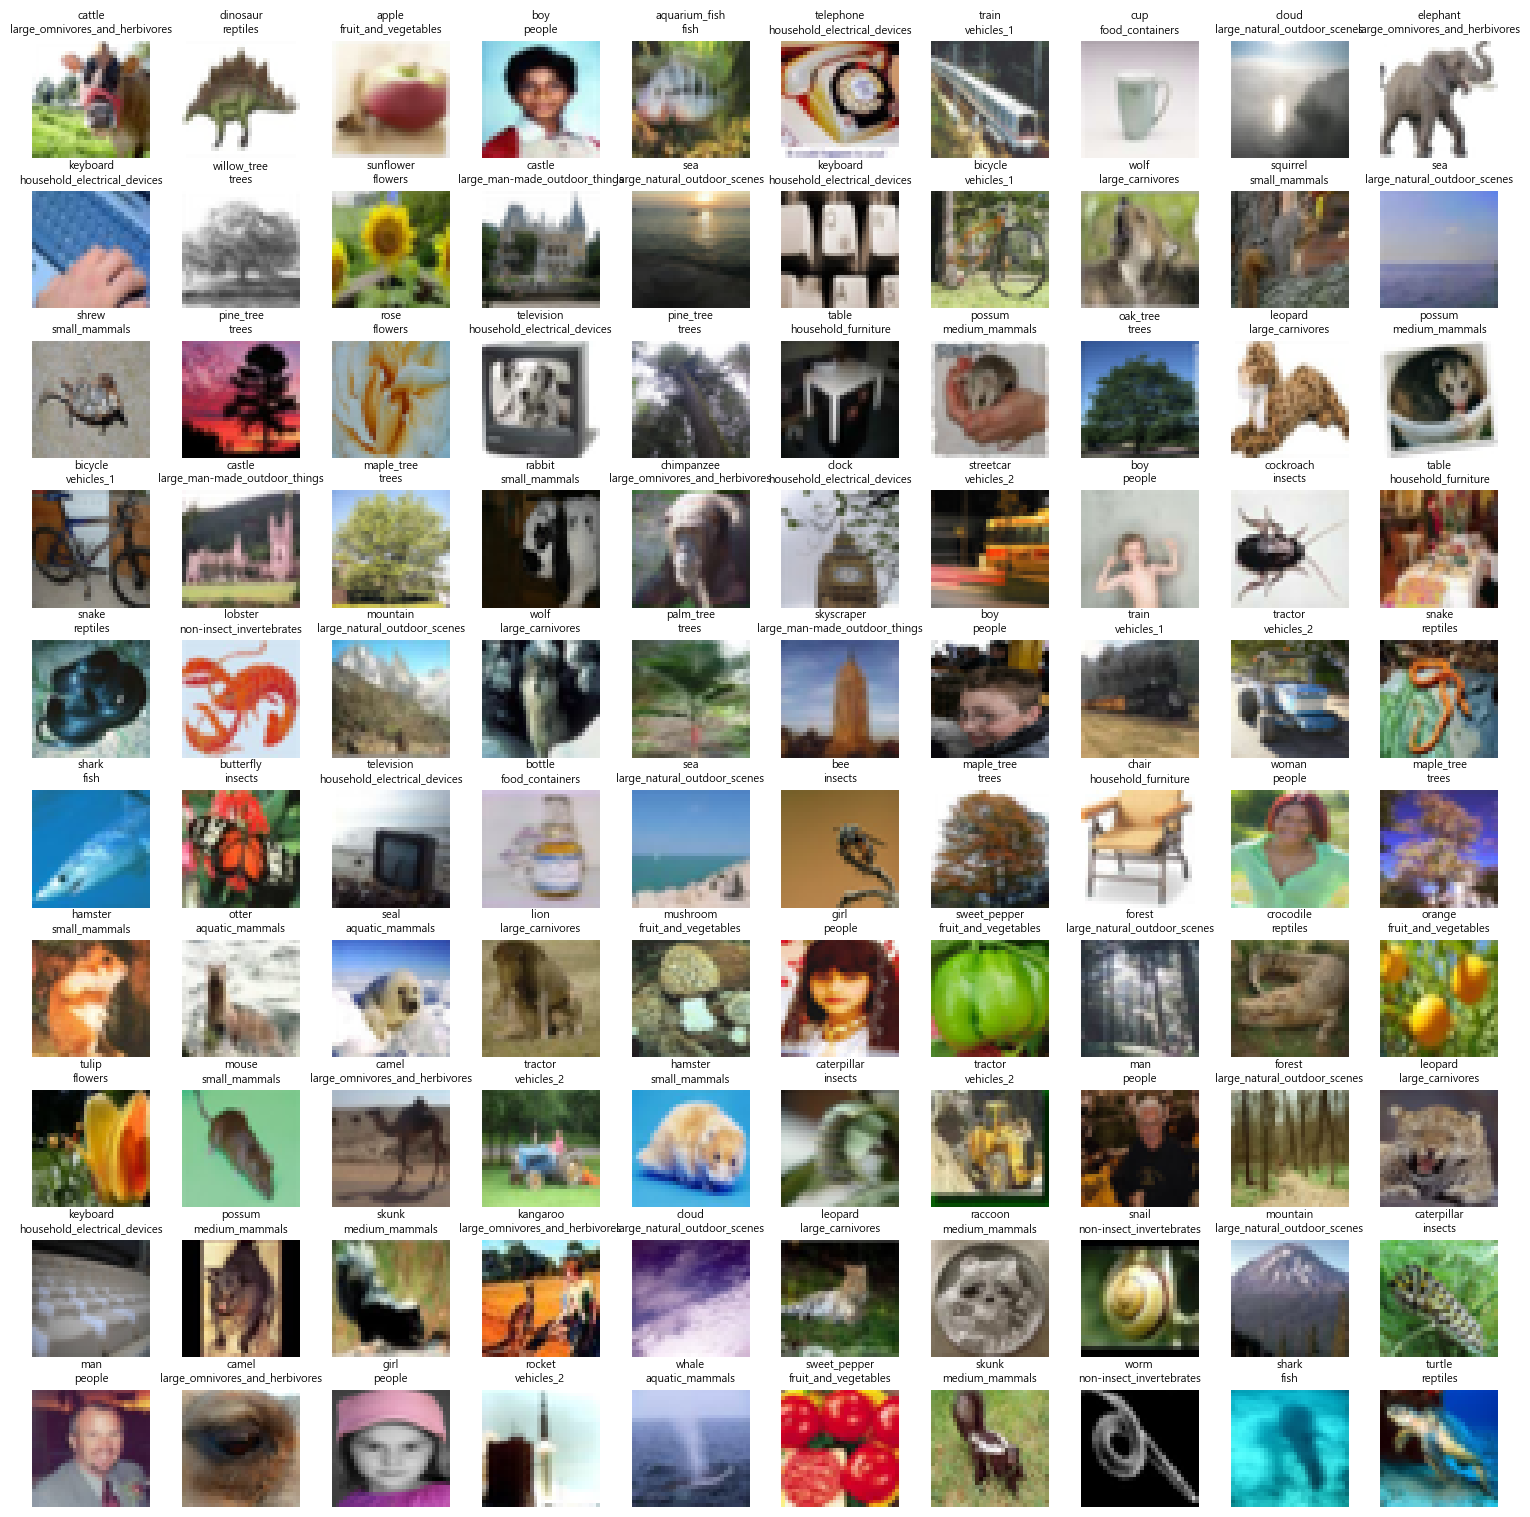

In [6]:
plt.figure(figsize=(15, 15))
for i in range(100):
    img = train_data[b'data'][i]
    img = img.reshape(3, 32, 32).transpose(1, 2, 0)
    img = img / 255.0

    fine_idx = train_data[b'fine_labels'][i]
    coarse_idx = train_data[b'coarse_labels'][i]
    fine_label = fine_label_names[fine_idx]
    coarse_label = coarse_label_names[coarse_idx]

    plt.subplot(10, 10, i + 1)
    plt.imshow(img)
    plt.title(f"{fine_label}\n{coarse_label}", fontsize=8)
    plt.axis('off')
    plt.subplots_adjust(wspace=0.05, hspace=0.05)  # 이미지 간격 최소화

plt.tight_layout(pad=0.1)
plt.show()

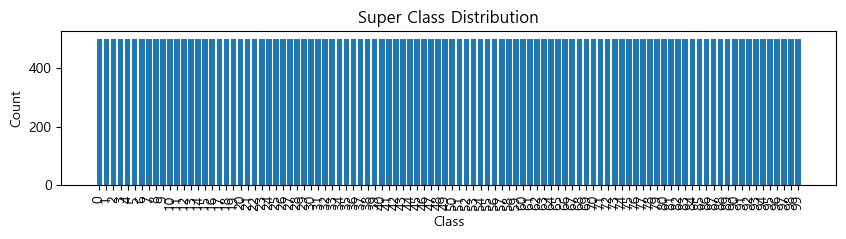

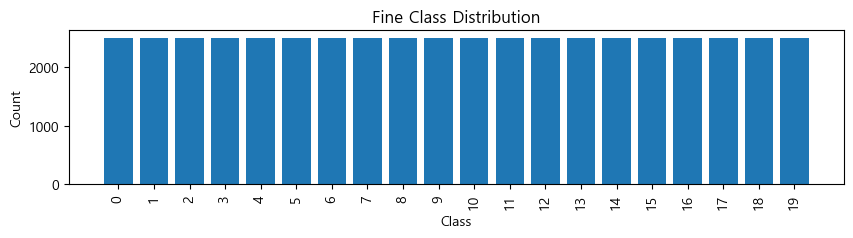

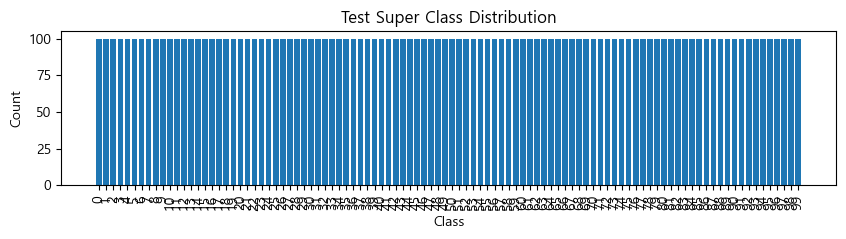

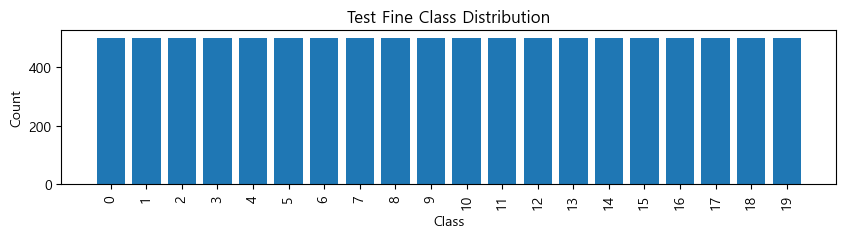

In [7]:
# 클래스 통계
def class_counts(data):
    unique, counts = np.unique(data[b'fine_labels'], return_counts=True)
    superclass_dict = dict(zip(unique, counts))
    unique, counts = np.unique(data[b'coarse_labels'], return_counts=True)
    class_dict = dict(zip(unique, counts))
    return superclass_dict, class_dict
superclass_counts, fineclass_counts = class_counts(train_data)
t_superclass_counts, t_fineclass_counts = class_counts(test_data)

# 클래스 통계 시각화
def plot_class_distribution(class_counts, title):
    plt.figure(figsize=(10, 2))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.xticks(list(class_counts.keys()), rotation=90)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.title(title)
    plt.show()
plot_class_distribution(superclass_counts, 'Super Class Distribution')
plot_class_distribution(fineclass_counts, 'Fine Class Distribution')
plot_class_distribution(t_superclass_counts, 'Test Super Class Distribution')
plot_class_distribution(t_fineclass_counts, 'Test Fine Class Distribution')

---
### 데이터 전처리

In [8]:
def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y.astype(int)]

# train set 으로 validation set 분할
x = train_data[b'data']
x = x.reshape(-1, 3, 32, 32)
t = np.array(train_data[b'coarse_labels'])
x_train, x_val, y_train, y_val = train_test_split(x, t, test_size=0.2, random_state=42, stratify=t)

# test set 정의
x_test = test_data[b'data']
x_test = x_test.reshape(-1, 3, 32, 32)
y_test = np.array(test_data[b'coarse_labels'])

x_test = x_test.astype(np.float32) / 255.0
x_train = x_train.astype(np.float32) / 255.0
x_val = x_val.astype(np.float32) / 255.0

y_train = one_hot_encode(y_train, 20)
y_val = one_hot_encode(y_val, 20)
y_test = one_hot_encode(y_test, 20)

x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape

((40000, 3, 32, 32),
 (10000, 3, 32, 32),
 (10000, 3, 32, 32),
 (40000, 20),
 (10000, 20),
 (10000, 20))

---
### 모델 정의 및 학습

In [9]:
# 기존 util.py 응용 - 출력을 정수형으로 변경
def conv_output_size(input_size, filter_size, stride=1, pad=0):
    return int((input_size + 2*pad - filter_size) / stride + 1)
def pool_output_size(input_size, pool_size, stride):
    return int(1 + (input_size - pool_size) / stride)

### L2 Norm 가이드
2. L2 Norm (Weight Decay) 적용

CustomCNN 모델의 손실 계산 부분에 L2 Norm (Weight Decay)을 추가하는 것은 과적합을 줄이는 데 매우 효과적인 방법입니다.

구현 방법:

가중치 가져오기: L2 규제를 적용할 가중치 파라미터들(주로 Affine 레이어와 Convolution 레이어의 가중치, 편향은 제외하는 경우가 많음)을 가져옵니다.
L2 Norm 계산: 선택된 가중치들의 제곱합을 계산합니다.
손실에 추가: 계산된 L2 Norm 값에 규제 강도(lambda, weight_decay_lambda 등으로 명명)를 곱하여 최종 손실에 더해줍니다.
역전파 시 그래디언트: L2 규제의 그래디언트는 lambda * W 입니다. 따라서 각 가중치 W의 그래디언트에 lambda * W를 더해주어야 합니다. 옵티마이저에서 이 부분을 처리하거나, 각 레이어의 backward 후 또는 Optimizer 클래스의 update 전에 이 그래디언트를 추가할 수 있습니다.
CustomCNN 또는 CustomTrainer 수정 예시:

CustomCNN의 loss 메소드 (또는 SoftmaxWithLoss 레이어와 별도로 Trainer에서 처리):
```python
# ... existing CustomCNN class ...

class CustomCNN:
    # ... existing __init__ and other methods ...

    def loss(self, x, t, train_flg=True, weight_decay_lambda=0.0):
        """
        손실 함수를 구한다.
        x : 입력 데이터
        t : 정답 레이블
        train_flg : 학습 중에는 True (Dropout, BatchNorm 활성화)
        weight_decay_lambda : L2 규제 강도 (0이면 적용 안 함)
        """
        y = self.predict(x, train_flg)

        # L2 규제 계산
        l2_norm = 0
        if weight_decay_lambda > 0:
            for layer_name in self.params: # 혹은 특정 레이어의 가중치만 선택
                if 'W' in layer_name: # 가중치 파라미터에 대해서만 (예: 'W1', 'W_conv1')
                    W = self.params[layer_name]
                    l2_norm += 0.5 * weight_decay_lambda * np.sum(W**2) # 0.5는 미분 시 상쇄용

        # 최종 손실 = 원래 손실 + L2 Norm
        # self.last_layer는 SoftmaxWithLoss의 인스턴스라고 가정
        return self.last_layer.forward(y, t) + l2_norm

    # ... existing gradient and other methods ...
```

CustomTrainer의 gradient (또는 train_step) 메소드:

만약 손실 함수에 직접 L2 Norm을 더하는 대신, 그래디언트에 직접 L2 페널티를 추가하는 방식을 선호한다면 (많은 라이브러리가 이렇게 구현합니다):
```python
# ... existing CustomTrainer class ...

class CustomTrainer:
    # ... existing __init__ and other methods ...

    def train_step(self):
        # ... 기존 미니배치 가져오기 ...

        # 기울기 계산 (역전파)
        self.network.loss(x_batch, t_batch, train_flg=True) # 순전파 및 SoftmaxWithLoss의 손실 계산
        self.network.gradient() # 역전파로 각 파라미터의 기본 그래디언트 계산
        grads = self.network.grads

        # L2 규제 그래디언트 추가 (옵티마이저 update 전에)
        if self.weight_decay_lambda > 0: # Trainer에 weight_decay_lambda 파라미터 추가 필요
            for key in self.network.params:
                if 'W' in key: # 가중치 파라미터에 대해서만
                    grads[key] += self.weight_decay_lambda * self.network.params[key]

        # 매개변수 갱신
        self.optimizer.update(self.network.params, grads)

        # ... 기존 손실 및 정확도 기록 ...
```
CustomTrainer 초기화 시 weight_decay_lambda 추가:
```python
# ...
trainer = CustomTrainer(network, x_train, y_train, x_val, y_val, x_test, y_test,
                        epochs=50, mini_batch_size=2048,
                        optimizer='Adam', optimizer_param={'lr': 0.002},
                        model_save_path=model_path+'/custom_cnn_best_model.npz',
                        weight_decay_lambda=0.0001) # 예시 값, 튜닝 필요
# ...
```
L2 규제 강도 (weight_decay_lambda): 이 값은 하이퍼파라미터이므로 튜닝이 필요합니다. 일반적으로 1e-3, 1e-4, 1e-5 와 같은 작은 값을 사용합니다. 너무 크면 과소적합(underfitting)이 발생할 수 있습니다.

데이터 증강과 L2 규제를 함께 적용하면 과적합을 효과적으로 제어하고 모델의 일반화 성능을 더욱 향상시킬 수 있을 것입니다. 두 가지 모두 직접 구현해야 하는 만큼 시간과 노력이 필요하겠지만, 딥러닝의 핵심 요소를 깊이 이해하는 데 큰 도움이 될 것입니다.

### 증강 적용 가이드

네, 맞습니다. generate_augment 메소드 시작 시 np.random.seed(self.random_state)를 호출하면, 그 이후에 _crop이나 _jitter 내부의 루프에서 np.random.randint()나 np.random.random()을 여러 번 호출할 때마다 NumPy의 RNG 내부 상태가 변경되면서 다른 랜덤 값들이 생성됩니다. 따라서 루프 내에서 매번 시드를 재설정할 필요는 없습니다.

제공해주신 DatasetAugmentator 코드는 이 원리를 잘 따르고 있습니다.

이제 CustomTrainer에서 DatasetAugmentator를 사용하여 매 에포크마다 데이터를 증강하고 학습하는 예제를 보여드리겠습니다. 기존 CustomTrainer의 구조를 최대한 유지하면서 필요한 부분을 추가하는 방향으로 작성하겠습니다.

수정 아이디어:

CustomTrainer의 __init__에서 DatasetAugmentator 인스턴스를 생성합니다.
train 메소드 내부의 에포크 루프 시작 부분에서 generate_augment를 호출하여 현재 에포크에 사용할 증강된 학습 데이터를 생성합니다.
증강된 데이터를 사용하여 미니배치 학습을 수행합니다.
(선택 사항) 매 에포크 평가 시 원본 학습 데이터 또는 증강된 학습 데이터 중 어떤 것을 사용할지 결정할 수 있습니다. 일반적으로는 증강된 데이터로 학습하고, 평가는 원본 검증/테스트 데이터로 수행합니다.
다음은 CustomTrainer 수정 예시입니다.

```python
# ...existing code...
class DatasetAugmentator:
    """
    데이터 증강을 위한 클래스
    내부 변수로 random state를 관리하며 매 epoch마다 1씩 증가하며 증강 수행
    Data shuffle 후 앞에서부터 num_aug만큼 잘라 변환 수행
    변환 후 기존 데이터와 병합하여 shuffle 후 반환
    지금은 flip, crop, jitter 3가지 증강 기법을 사용 - 늘어나면 전체적인 코드 수정 필요

    Parameters
    ----------
    num_aug : int
        각 증강 기법을 적용할 데이터 수
    initial_seed : int
        랜덤 시드 초기값

    Returns
    -------
    X : numpy.ndarray
        증강된 데이터
    Y : numpy.ndarray
        증강된 레이블
    
    Raises
    -------
    ValueError
        num_aug*3 > len(X)인 경우 방지
    """
    def __init__(self, num_aug=5000, initial_seed=42):
        self.num_aug = num_aug
        self.random_state = initial_seed

    def generate_augment(self, X, y): # 원본 데이터를 X, y로 받음
        np.random.seed(self.random_state)
        print(f"DatasetAugmentator: 증강 시작 (Seed: {self.random_state})") # 로그 추가

        num_samples = X.shape[0]
        if self.num_aug <= 0 :
            raise ValueError("num_aug는 0보다 커야 합니다.")
        if self.num_aug * 3 > num_samples: # num_aug는 각 증강별 샘플 수이므로 *3
            raise ValueError(f"num_aug*3 ({self.num_aug*3})은 원본 데이터 크기({num_samples})보다 작거나 같아야 합니다.")
        
        # 원본 데이터를 복사하여 사용 (셔플 시 원본 데이터 순서 변경 방지)
        X_shuffled, y_shuffled = shuffle_dataset(X.copy(), y.copy())

        # 변환할 인덱스
        idx_flip_end = self.num_aug
        idx_crop_end = self.num_aug * 2
        idx_jitter_end = self.num_aug * 3

        # 대상 샘플 선정 및 변환 수행
        # 슬라이싱된 데이터도 복사본으로 만들어 이후 연산이 원본 X_shuffled에 영향 주지 않도록 함
        X_to_flip, y_to_flip = X_shuffled[:idx_flip_end].copy(), y_shuffled[:idx_flip_end].copy()
        X_to_crop, y_to_crop = X_shuffled[idx_flip_end:idx_crop_end].copy(), y_shuffled[idx_flip_end:idx_crop_end].copy()
        X_to_jitter, y_to_jitter = X_shuffled[idx_crop_end:idx_jitter_end].copy(), y_shuffled[idx_crop_end:idx_jitter_end].copy()
        
        X_flipped = self._flip(X_to_flip)
        X_cropped = self._crop(X_to_crop) # _crop 내부의 np.random은 generate_augment 시작 시 설정된 시드의 영향을 받음
        X_jittered = self._jitter(X_to_jitter) # _jitter 내부의 np.random도 동일

        # 증강된 데이터와 "원본" 데이터(X, y) 병합
        X_aug = np.concatenate((X, X_flipped, X_cropped, X_jittered), axis=0)
        y_aug = np.concatenate((y, y_to_flip, y_to_crop, y_to_jitter), axis=0) # 레이블도 해당 증강 이미지의 레이블 사용
        
        # 병합 후 다시 섞기
        X_final, y_final = shuffle_dataset(X_aug, y_aug)
        
        # 랜덤 시드 증가
        self.random_state += 1
        print(f"  - 증강 후 데이터셋 크기: {X_final.shape[0]}, 다음 시드: {self.random_state}") # 로그 추가
        return X_final, y_final

    # flip 정의
    def _flip(self, X):
        return X[:, :, :, ::-1] # 좌우 반전
    # crop 정의 - padding후 랜덤하게 crop
    def _crop(self, X, padding=4):
        if X.shape[0] == 0: return X # 빈 배열 처리
        X_padded = np.pad(X, pad_width=((0, 0), (0, 0), (padding, padding), (padding, padding)), mode='constant', constant_values=0)
        X_pad_crop = np.empty_like(X)
        h_orig, w_orig = X.shape[2], X.shape[3]
        for i in range(X.shape[0]):
            # generate_augment에서 np.random.seed가 이미 설정되었으므로,
            # 여기서 np.random.randint는 그 시드 상태를 이어받아 랜덤 값을 생성함.
            top = np.random.randint(0, padding * 2 + 1)
            left = np.random.randint(0, padding * 2 + 1)
            X_pad_crop[i] = X_padded[i, :, top:top + h_orig, left:left + w_orig]
        return X_pad_crop
    # jitter 정의 - 밝기 조절, 나중에 색상, 채도 등 추가 가능
    def _jitter(self, X):
        if X.shape[0] == 0: return X # 빈 배열 처리
        X_jitter_out = np.empty_like(X)
        for i in range(X.shape[0]):
            # generate_augment에서 np.random.seed가 이미 설정되었으므로,
            # 여기서 np.random.random은 그 시드 상태를 이어받아 랜덤 값을 생성함.
            brightness_factor = 0.7 + (0.6 * np.random.random()) # 이미지 전체에 동일한 factor 적용
            X_jitter_out[i] = np.clip(X[i] * brightness_factor, 0.0, 1.0)
        return X_jitter_out

class CustomTrainer:
    """
    신경망 훈련을 수행하는 클래스.
    학습, 검증, 테스트 데이터를 모두 사용하며, 학습 과정을 기록하고 최적 모델을 저장합니다.
    데이터 증강 기능을 포함합니다.
    """
    def __init__(self, network, 
                 x_train_orig, t_train_orig, x_val, t_val, x_test, t_test, # 원본 학습 데이터를 _orig로 받음
                 epochs=20, mini_batch_size=100,
                 optimizer='Adam', optimizer_param={'lr':0.001}, 
                 verbose=True, model_save_path='best_model.npz',
                 use_augmentation=False, augmentator_params=None): # 증강 사용 여부 및 파라미터 추가
        
        self.network = network
        self.x_train_orig = x_train_orig # 원본 학습 데이터 저장
        self.t_train_orig = t_train_orig
        self.x_val = x_val
        self.t_val = t_val
        self.x_test = x_test
        self.t_test = t_test
        
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.verbose = verbose
        self.model_save_path = model_save_path

        self.use_augmentation = use_augmentation
        if self.use_augmentation:
            if augmentator_params is None:
                augmentator_params = {} # 기본값 사용
            self.augmentator = DatasetAugmentator(**augmentator_params)
        else:
            self.augmentator = None

        # Optimizer 설정
        optimizer_class_dict = {'sgd':SGD, 'momentum':Momentum, 'nesterov':Nesterov,
                                'adagrad':AdaGrad, 'rmsprop':RMSprop, 'adam':Adam}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)
        
        # train_size는 에포크마다 달라질 수 있으므로 train 루프에서 업데이트
        self.current_x_train = self.x_train_orig
        self.current_t_train = self.t_train_orig
        self.train_size = self.current_x_train.shape[0]
        self.iter_per_epoch = max(self.train_size // self.batch_size, 1)
        self.max_iter = int(epochs * self.iter_per_epoch) # 참고용, 실제로는 iter_per_epoch 기준으로 루프
        
        self.best_val_loss = float('inf')
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    def _train_step(self):
        # 미니배치 획득 (현재 에포크의 학습 데이터에서)
        batch_mask = np.random.choice(self.train_size, self.batch_size)
        x_batch = self.current_x_train[batch_mask]
        t_batch = self.current_t_train[batch_mask]
        
        # 기울기 계산 및 파라미터 갱신
        grads = self.network.gradient(x_batch, t_batch) # train_flg=True는 gradient 내부 loss에서 처리
        self.optimizer.update(self.network.params, grads)
    
    def train(self):
        for epoch in range(1, self.epochs + 1):
            # --- 데이터 증강 (매 에포크 시작 시) ---
            if self.use_augmentation and self.augmentator:
                print(f"Epoch {epoch}/{self.epochs}: 데이터 증강 수행 중...")
                # 원본 학습 데이터를 기반으로 증강
                self.current_x_train, self.current_t_train = self.augmentator.generate_augment(
                    self.x_train_orig, self.t_train_orig
                )
                # 증강된 데이터셋에 맞춰 train_size 및 iter_per_epoch 업데이트
                self.train_size = self.current_x_train.shape[0]
                self.iter_per_epoch = max(self.train_size // self.batch_size, 1)
                print(f"  증강된 학습 데이터 크기: {self.train_size}, 배치 당 반복 수: {self.iter_per_epoch}")
            else:
                # 증강 사용 안 할 시 원본 데이터 사용
                self.current_x_train = self.x_train_orig
                self.current_t_train = self.t_train_orig
                self.train_size = self.current_x_train.shape[0]
                self.iter_per_epoch = max(self.train_size // self.batch_size, 1)


            # tqdm을 사용하여 미니배치 학습 진행 표시
            with tqdm(range(self.iter_per_epoch), desc=f"Epoch {epoch}/{self.epochs} Training", unit="batch", leave=False) as pbar:
                for i_iter in pbar:
                    self._train_step()
                    # tqdm 설명에 현재 미니배치 손실 등을 표시하고 싶다면 _train_step에서 loss를 반환받아 pbar.set_postfix 등으로 설정 가능

            # --- 1 에포크 종료 후 평가 ---
            # 학습 데이터에 대한 손실 및 정확도 (현재 에포크의 학습 데이터 기준)
            # 주의: 증강된 데이터 전체에 대해 평가하면 시간이 오래 걸릴 수 있음.
            # 필요시 일부 샘플만 사용하거나, 원본 학습 데이터로 평가할 수 있음. 여기서는 현재 학습 데이터로 평가.
            current_train_loss = self.network.batch_loss(self.current_x_train, self.current_t_train, batch_size=self.batch_size, label=f"Epoch {epoch} Train Loss")
            current_train_acc = self.network.batch_accuracy(self.current_x_train, self.current_t_train, batch_size=self.batch_size, label=f"Epoch {epoch} Train Acc")

            # 검증 데이터에 대한 손실 및 정확도 (항상 원본 검증 데이터 사용)
            current_val_loss = self.network.batch_loss(self.x_val, self.t_val, batch_size=self.batch_size, label=f"Epoch {epoch} Val Loss")
            current_val_acc = self.network.batch_accuracy(self.x_val, self.t_val, batch_size=self.batch_size, label=f"Epoch {epoch} Val Acc")

            # History 기록
            self.history['train_loss'].append(current_train_loss)
            self.history['train_acc'].append(current_train_acc)
            self.history['val_loss'].append(current_val_loss)
            self.history['val_acc'].append(current_val_acc)

            if self.verbose:
                print(f"Epoch {epoch}/{self.epochs} Summary: \n"
                      f"  - Train Loss: {current_train_loss:.4f}, Train Acc: {current_train_acc:.4f}\n"
                      f"  - Val Loss  : {current_val_loss:.4f}, Val Acc  : {current_val_acc:.4f}")

            # 최소 검증 손실 모델 저장
            if current_val_loss < self.best_val_loss:
                self.best_val_loss = current_val_loss
                save_msg = self.network.save_params(self.model_save_path)
                if self.verbose:
                    print(f"  -> Best model saved. {save_msg} (Val Loss: {self.best_val_loss:.4f})", flush=True)
        
        # --- 학습 종료 후 최종 테스트 평가 ---
        if self.verbose:
            print("\n=============== Final Test Evaluation ===============")
        
        # 테스트는 항상 원본 테스트 데이터로 수행
        test_loss = self.network.batch_loss(self.x_test, self.t_test, batch_size=self.batch_size, label="Test Loss") # batch_loss 사용
        test_acc = self.network.batch_accuracy(self.x_test, self.t_test, batch_size=self.batch_size, label="Test Acc") # batch_accuracy 사용
        
        if self.verbose:
            print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
            
        return self.history

# ... CustomCNN 클래스 정의 ...

# --- 사용 예시 ---
# time_date = '250517_0900' # 예시 시간
# model_path_root = f'./saved_model/model_{time_date}'
# os.makedirs(model_path_root, exist_ok=True)

# network_aug = CustomCNN(verbose=False, fc_dropout_ratio=0.3)

# # 데이터 증강 설정
# augmentator_settings = {'num_aug': 5000, 'initial_seed': 42} # CIFAR-10 학습 데이터 40000개 기준, 5000개씩 3종류 증강

# trainer_aug = CustomTrainer(network_aug, 
#                             x_train, y_train, x_val, y_val, x_test, y_test, # x_train, y_train은 원본 학습 데이터
#                             epochs=50, mini_batch_size=256, # 배치 사이즈는 증강 후 데이터 크기 고려
#                             optimizer='Adam', optimizer_param={'lr':0.001},
#                             model_save_path=model_path_root+'/custom_cnn_aug_best_model.npz',
#                             use_augmentation=True, # 증강 사용 True
#                             augmentator_params=augmentator_settings,
#                             verbose=True)

# history_aug = trainer_aug.train()
# pickle.dump(history_aug, open(model_path_root+'/custom_cnn_aug_history.pkl', 'wb'))
# print(f"Augmented training history saved to {model_path_root}")

# # 증강 없이 학습하는 경우 (비교용)
# # network_no_aug = CustomCNN(verbose=False, fc_dropout_ratio=0.3)
# # trainer_no_aug = CustomTrainer(network_no_aug,
# #                                x_train, y_train, x_val, y_val, x_test, y_test,
# #                                epochs=50, mini_batch_size=256, # 원본 데이터 기준 배치 사이즈
# #                                optimizer='Adam', optimizer_param={'lr':0.001},
# #                                model_save_path=model_path_root+'/custom_cnn_no_aug_best_model.npz',
# #                                use_augmentation=False, # 증강 사용 False
# #                                verbose=True)
# # history_no_aug = trainer_no_aug.train()
# # pickle.dump(history_no_aug, open(model_path_root+'/custom_cnn_no_aug_history.pkl', 'wb'))
# # print(f"Non-augmented training history saved to {model_path_root}")

```

주요 변경점 및 설명:

DatasetAugmentator 수정:

generate_augment 메소드에 로그를 추가하여 시드 값과 증강 후 데이터 크기를 출력하도록 했습니다.
num_aug 관련 ValueError 메시지를 좀 더 명확하게 수정했습니다.
shuffle_dataset(X.copy(), y.copy())와 같이 입력 데이터의 복사본을 사용하여 원본 X, y가 변경되지 않도록 명시했습니다. (만약 shuffle_dataset이 이미 내부적으로 복사한다면 .copy()는 생략 가능하지만, 안전을 위해 추가하는 것이 좋습니다.)
증강 대상을 슬라이싱할 때도 .copy()를 추가하여 이후 연산이 X_shuffled에 영향을 주지 않도록 했습니다.
_crop, _jitter에서 입력 X가 비어있는 경우를 처리하는 간단한 방어 코드를 추가했습니다.
_jitter에서 brightness_factor가 이미지 전체에 적용되도록 스칼라 값으로 수정했습니다.
CustomTrainer.__init__ 수정:

x_train, t_train 대신 x_train_orig, t_train_orig로 원본 학습 데이터를 받도록 변경했습니다.
use_augmentation (boolean) 및 augmentator_params (dict) 인자를 추가하여 데이터 증강 사용 여부와 DatasetAugmentator의 설정을 제어할 수 있도록 했습니다.
use_augmentation이 True이면 DatasetAugmentator 인스턴스를 생성합니다.
current_x_train, current_t_train을 두어 현재 에포크에서 사용할 학습 데이터를 관리합니다. 초기에는 원본 데이터를 가리킵니다.
train_size와 iter_per_epoch는 에포크 시작 시점에 (증강 후) 결정되도록 로직을 옮겼습니다.
CustomTrainer.train 메소드 수정:

매 에포크 시작 시 데이터 증강: use_augmentation이 True이면 self.augmentator.generate_augment()를 호출하여 self.current_x_train과 self.current_t_train을 업데이트합니다.
증강된 데이터셋의 크기에 맞춰 self.train_size와 self.iter_per_epoch를 다시 계산합니다.
증강을 사용하지 않으면 current_x_train 등은 원본 데이터를 계속 사용합니다.
학습 및 평가: _train_step은 self.current_x_train을 사용합니다. 에포크 종료 후 학습 데이터에 대한 평가는 self.current_x_train (증강되었을 수 있는 데이터)을 사용하고, 검증 및 테스트 데이터에 대한 평가는 항상 원본(self.x_val, self.x_test)을 사용합니다.
network.loss 및 network.accuracy 대신 network.batch_loss 및 network.batch_accuracy를 테스트 평가 시에도 사용하도록 통일했습니다 (메모리 관리 측면에서 더 안전).
사용 예시:

CustomTrainer를 인스턴스화할 때 use_augmentation=True와 augmentator_params를 전달하여 증강 기능을 활성화하는 방법을 보여줍니다.
mini_batch_size는 증강으로 인해 데이터셋 크기가 커질 것을 고려하여 적절히 설정해야 합니다.
이 코드는 DatasetAugmentator를 CustomTrainer에 통합하여 에포크마다 데이터 증강을 수행하고, 그 증강된 데이터로 모델을 학습시키는 과정을 보여줍니다. 기존 코드의 흐름을 최대한 유지하면서 필요한 기능을 추가하려고 노력했습니다.

In [10]:
def apply_label_smoothing(t, smoothing=0.1):
    """
    t: (batch_size, num_classes) - one-hot labels
    smoothing: float - e.g., 0.1

    Returns:
    smoothed labels: (batch_size, num_classes)
    """
    num_classes = t.shape[1]
    return (1 - smoothing) * t + (smoothing / num_classes)


In [11]:
import numpy as np

# 증강 함수 정의
def flip(img, _):  # 좌우 반전
    return np.flip(img, axis=2)

def cutout(img, size):  # 패치 제거
    _, h, w = img.shape
    y, x = np.random.randint(h), np.random.randint(w)
    y1, y2 = max(0, y - size // 2), min(h, y + size // 2)
    x1, x2 = max(0, x - size // 2), min(w, x + size // 2)
    img[:, y1:y2, x1:x2] = 0
    return img

def brightness(img, mag):
    scale = 1 + mag * (np.random.rand() * 2 - 1)
    return np.clip(img * scale, 0, 1)

def contrast(img, mag):
    mean = np.mean(img, axis=(1, 2), keepdims=True)
    scale = 1 + mag * (np.random.rand() * 2 - 1)
    return np.clip((img - mean) * scale + mean, 0, 1)

def crop(img, pad):
    C, H, W = img.shape
    padded = np.pad(img, ((0, 0), (pad, pad), (pad, pad)), mode='reflect')
    top = np.random.randint(0, 2 * pad)
    left = np.random.randint(0, 2 * pad)
    return padded[:, top:top + H, left:left + W]

# 연산 및 강도 매핑
AUGMENT_FN = {
    'flip': flip,
    'cutout': cutout,
    'brightness': brightness,
    'contrast': contrast,
    'crop': crop,
}

AUGMENT_MAG = {
    'flip': None,
    'cutout': lambda m: int(32 * (m / 10)),
    'brightness': lambda m: 0.9 * (m / 10),
    'contrast': lambda m: 0.9 * (m / 10),
    'crop': lambda m: int(8 * (m / 10)),
}

# RandAugment 적용 (이미지 1장)
def apply_randaugment(img, N=2, M=9):
    ops = list(AUGMENT_FN.keys())
    chosen = np.random.choice(ops, size=N, replace=False)
    for op_name in chosen:
        fn = AUGMENT_FN[op_name]
        mag_fn = AUGMENT_MAG[op_name]
        mag = mag_fn(M) if mag_fn else None
        img = fn(img, mag)
    return img

# 배치 단위 RandAugment
def randaugment_batch(x_batch, N=2, M=9):
    new_batch = np.empty_like(x_batch)
    for i in range(x_batch.shape[0]):
        new_batch[i] = apply_randaugment(x_batch[i], N, M)
    return new_batch


In [12]:
def cutmix_batch(x_batch, t_batch, alpha=1.0):
    """CutMix 증강 (배치 기준)"""
    N, C, H, W = x_batch.shape
    indices = np.random.permutation(N)
    x1, x2 = x_batch, x_batch[indices]
    y1, y2 = t_batch, t_batch[indices]

    lam = np.random.beta(alpha, alpha)
    rx = np.random.randint(W)
    ry = np.random.randint(H)
    rw = int(W * np.sqrt(1 - lam))
    rh = int(H * np.sqrt(1 - lam))

    x1_l, x1_r = np.clip(rx - rw // 2, 0, W), np.clip(rx + rw // 2, 0, W)
    y1_t, y1_b = np.clip(ry - rh // 2, 0, H), np.clip(ry + rh // 2, 0, H)

    x_cutmix = x1.copy()
    x_cutmix[:, :, y1_t:y1_b, x1_l:x1_r] = x2[:, :, y1_t:y1_b, x1_l:x1_r]

    lam_adj = 1 - ((x1_r - x1_l) * (y1_b - y1_t) / (H * W))
    t_cutmix = lam_adj * y1 + (1 - lam_adj) * y2

    return x_cutmix, t_cutmix


In [13]:
def warmup_scheduler(base_lr, warmup_epochs, current_epoch):
    """
    초기 warmup_epochs 동안 base_lr까지 선형 증가.
    """
    if current_epoch < warmup_epochs:
        return base_lr * (current_epoch + 1) / warmup_epochs
    else:
        return base_lr
    
def cosine_annealing_scheduler(base_lr, min_lr, total_epochs, current_epoch):
    """
    warmup 종료 이후 cosine 곡선으로 감소.
    """
    progress = current_epoch / total_epochs
    cosine_decay = 0.5 * (1 + np.cos(np.pi * progress))
    return min_lr + (base_lr - min_lr) * cosine_decay

def cosine_warmup_scheduler(base_lr, min_lr, warmup_epochs, total_epochs, current_epoch):
    """
    전체 스케줄러: warmup_epochs 이내면 선형 증가,
    이후는 cosine annealing 적용.
    """
    if current_epoch < warmup_epochs:
        return warmup_scheduler(base_lr, warmup_epochs, current_epoch)
    else:
        # cosine 영역에서의 progress를 조정해서 전체 기간 중 일부만 cosine 적용
        cosine_epoch = current_epoch - warmup_epochs
        cosine_total = total_epochs - warmup_epochs
        return cosine_annealing_scheduler(base_lr, min_lr, cosine_total, cosine_epoch)


In [14]:
class CustomCNN:
    # 모델 구조
    # ConvB1 : C1(16) -> R -> C2(32) -> R -> P1
    # ConvB2 : C3(64) -> R -> C4(128) -> R -> P2
    # Dense1 : Affine1(256) -> R -> BN1 -> Drop1
    # Dense2 : Affine2(256) -> R -> BN2 -> Drop2
    # Affine_out(output_size)
    # util.py 내 im2col 연산 float32로 변경 필요
    def __init__(self, input_dim=(3, 32, 32),
                C1={'filter_num':16, 'filter_size':3, 'pad':1, 'stride':1},
                C2={'filter_num':32, 'filter_size':3, 'pad':1, 'stride':1},
                P1={'pool_h':2, 'pool_w':2, 'stride':2},
                C3={'filter_num':64, 'filter_size':3, 'pad':1, 'stride':1},
                C4={'filter_num':128, 'filter_size':3, 'pad':1, 'stride':1},
                P2={'pool_h':2, 'pool_w':2, 'stride':2},
                weight_init_std=0.01,
                fc_hidden_size_list=[256,256], fc_output_size=20,
                fc_activation='relu', fc_weight_std='he',
                fc_dropout_ratio=0.5, fc_use_batchnorm=True,
                verbose=True):
        
        self.verbose = verbose
        self.use_dropout = fc_dropout_ratio > 0
        self.use_batchnorm = fc_use_batchnorm
        self.fc_dropout_ratio = fc_dropout_ratio
        self.weight_init_std = weight_init_std # 가중치 초기화 방법 지정(또는 숫자)

        # Input, Conv, Pooling params
        input_c, input_h, input_w = input_dim
        if verbose: print(f"Input shape: {input_dim}")  # 추가: 입력 shape 확인
            # ConvB1
        C1_fn, C1_fs, C1_p, C1_s= C1['filter_num'], C1['filter_size'], C1['pad'], C1['stride']
        C2_fn, C2_fs, C2_p, C2_s= C2['filter_num'], C2['filter_size'], C2['pad'], C2['stride']
        P1_ph, P1_pw, P1_s= P1['pool_h'], P1['pool_w'], P1['stride']
           # ConvB2
        C3_fn, C3_fs, C3_p, C3_s= C3['filter_num'], C3['filter_size'], C3['pad'], C3['stride']
        C4_fn, C4_fs, C4_p, C4_s= C4['filter_num'], C4['filter_size'], C4['pad'], C4['stride']
        P2_ph, P2_pw, P2_s= P2['pool_h'], P2['pool_w'], P2['stride']
        
        #layer_init 전달용, 레이어 구성 바뀌면 바꿔야함
        self.layer_settings = {'C1_s':C1_s, 'C1_p':C1_p, 'C2_s':C2_s, 'C2_p':C2_p,
                               'P1_ph':P1_ph, 'P1_pw':P1_pw, 'P1_s':P1_s,
                               'C3_s':C3_s, 'C3_p':C3_p, 'C4_s':C4_s, 'C4_p':C4_p,
                               'P2_ph':P2_ph, 'P2_pw':P2_pw, 'P2_s':P2_s}
           
        # Conv, Pooling Shape
            # ConvB1
        C1_out_h = conv_output_size(input_h, C1_fs, C1_s, C1_p)
        C1_out_w = conv_output_size(input_w, C1_fs, C1_s, C1_p)
        C2_out_h = conv_output_size(C1_out_h, C2_fs, C2_s, C2_p)
        C2_out_w = conv_output_size(C1_out_w, C2_fs, C2_s, C2_p)
        P1_out_h = pool_output_size(C2_out_h, P1_ph, P1_s)
        P1_out_w = pool_output_size(C2_out_w, P1_pw, P1_s)
            # ConvB2
        C3_out_h = conv_output_size(P1_out_h, C3_fs, C3_s, C3_p)
        C3_out_w = conv_output_size(P1_out_w, C3_fs, C3_s, C3_p)
        C4_out_h = conv_output_size(C3_out_h, C4_fs, C4_s, C4_p)
        C4_out_w = conv_output_size(C3_out_w, C4_fs, C4_s, C4_p)
        P2_out_h = pool_output_size(C4_out_h, P2_ph, P2_s)
        P2_out_w = pool_output_size(C4_out_w, P2_pw, P2_s)
            # Affine Size
        fc_input_size = int(C4_fn * P2_out_h * P2_out_w)
        if verbose: print(f"FC input size: {fc_input_size}")  # 추가

        # 가중치 초기화
        self.params = {}
        self.bn_params = {}
            #ConvB1
        self.params['W1'] = self._get_init_weight(prev_node_num=input_c*C1_fs**2) * np.random.randn(C1_fn, input_c, C1_fs, C1_fs)
        self.params['b1'] = np.zeros(C1_fn, dtype=np.float32)
        self.params['W2'] = self._get_init_weight(prev_node_num=C1_fn*C2_fs**2) * np.random.randn(C2_fn, C1_fn, C2_fs, C2_fs)
        self.params['b2'] = np.zeros(C2_fn, dtype=np.float32)
            #ConvB2
        self.params['W3'] = self._get_init_weight(prev_node_num=C2_fn*C3_fs**2) * np.random.randn(C3_fn, C2_fn, C3_fs, C3_fs)
        self.params['b3'] = np.zeros(C3_fn, dtype=np.float32)
        self.params['W4'] = self._get_init_weight(prev_node_num=C3_fn*C4_fs**2) * np.random.randn(C4_fn, C3_fn, C4_fs, C4_fs)
        self.params['b4'] = np.zeros(C4_fn, dtype=np.float32)
            # FC Layer
        self.params['W5'] = self._get_init_weight(prev_node_num=fc_input_size) * np.random.randn(fc_input_size, fc_hidden_size_list[0])
        self.params['b5'] = np.zeros(fc_hidden_size_list[0], dtype=np.float32)
        self.params['W6'] = self._get_init_weight(prev_node_num=fc_hidden_size_list[0]) * np.random.randn(fc_hidden_size_list[0], fc_hidden_size_list[1])
        self.params['b6'] = np.zeros(fc_hidden_size_list[1], dtype=np.float32)
        self.params['W7'] = self._get_init_weight(prev_node_num=fc_hidden_size_list[1]) * np.random.randn(fc_hidden_size_list[1], fc_output_size)
        self.params['b7'] = np.zeros(fc_output_size, dtype=np.float32)
            # BN
        if fc_use_batchnorm:
            self.params['gamma5'] = np.ones(fc_hidden_size_list[0])
            self.params['beta5'] = np.zeros(fc_hidden_size_list[0], dtype=np.float32)
            self.bn_params['running_mean5'] = np.zeros(fc_hidden_size_list[0], dtype=np.float32)
            self.bn_params['running_var5'] = np.ones(fc_hidden_size_list[0], dtype=np.float32)
            self.params['gamma6'] = np.ones(fc_hidden_size_list[1])
            self.params['beta6'] = np.zeros(fc_hidden_size_list[1], dtype=np.float32)
            self.bn_params['running_mean6'] = np.zeros(fc_hidden_size_list[1], dtype=np.float32)
            self.bn_params['running_var6'] = np.ones(fc_hidden_size_list[1], dtype=np.float32)
        # 레이어 구성 함수 호출
        self._layer_init(self.layer_settings)
    
    def _layer_init(self, layer_setting):
        # 레이어 구성
        self.layers = OrderedDict()
            # ConvB1
        self.layers['C1'] = Convolution(self.params['W1'], self.params['b1'], stride=layer_setting['C1_s'], pad=layer_setting['C1_p'])
        self.layers['R1'] = Relu()
        self.layers['C2'] = Convolution(self.params['W2'], self.params['b2'], stride=layer_setting['C2_s'], pad=layer_setting['C2_p'])
        self.layers['R2'] = Relu()
        self.layers['P1'] = Pooling(pool_h=layer_setting['P1_ph'], pool_w=layer_setting['P1_pw'], stride=layer_setting['P1_s'])
            # ConvB2
        self.layers['C3'] = Convolution(self.params['W3'], self.params['b3'], stride=layer_setting['C3_s'], pad=layer_setting['C3_p'])
        self.layers['R3'] = Relu()
        self.layers['C4'] = Convolution(self.params['W4'], self.params['b4'], stride=layer_setting['C4_s'], pad=layer_setting['C4_p'])
        self.layers['R4'] = Relu()
        self.layers['P2'] = Pooling(pool_h=layer_setting['P2_ph'], pool_w=layer_setting['P2_pw'], stride=layer_setting['P2_s'])
            # FC B1
        self.layers['Affine1'] = Affine(self.params['W5'], self.params['b5'])
        if self.use_batchnorm: self.layers['BN1'] = BatchNormalization(self.params['gamma5'], self.params['beta5'], running_mean=self.bn_params['running_mean5'], running_var=self.bn_params['running_var5'])
        self.layers['R5'] = Relu()
        if self.use_dropout: self.layers['Drop1'] = Dropout(self.fc_dropout_ratio)
            # FC B2
        self.layers['Affine2'] = Affine(self.params['W6'], self.params['b6'])
        if self.use_batchnorm: self.layers['BN2'] = BatchNormalization(self.params['gamma6'], self.params['beta6'], running_mean=self.bn_params['running_mean6'], running_var=self.bn_params['running_var6'])
        self.layers['R6'] = Relu()
        if self.use_dropout: self.layers['Drop2'] = Dropout(self.fc_dropout_ratio)
            # Output
        self.layers['Affine_out'] = Affine(self.params['W7'], self.params['b7'])
        self.last_layer = SoftmaxWithLoss()

    def _get_init_weight(self, prev_node_num = None):
        if self.weight_init_std == 'relu' or self.weight_init_std == 'he':
            return np.sqrt(2.0 / prev_node_num)
        else:
            return self.weight_init_std

    def predict(self, x, train_flg=False):
        for name, layer in self.layers.items():
            if isinstance(layer, (Dropout, BatchNormalization)):
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)
            if self.verbose:
                print(f"{name} output shape: {x.shape}")
                if name in ['Affine1', 'Affine2'] and not self.use_batchnorm:
                    print(f"  Stats for {name} output (pre-ReLU): mean={np.mean(x):.4f}, std={np.std(x):.4f}, min={np.min(x):.4f}, max={np.max(x):.4f}")
        return x

    def loss(self, x, t, train_flg=False):
        y = self.predict(x, train_flg)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, train_flg=False):
        y = self.predict(x, train_flg)
        y = np.argmax(y, axis=1)
        if t.ndim != 1:
            t = np.argmax(t, axis=1)
        return np.sum(y == t) / float(x.shape[0])
    
    # 램용량 넘쳐서 batch 처리
    def batch_loss(self, x, t, batch_size=100, label="Loss"):
        loss = 0
        size = x.shape[0]
        for i in tqdm(range(0, size, batch_size), desc=label, leave=False):
            x_batch = x[i:i+batch_size]
            t_batch = t[i:i+batch_size]
            loss += self.loss(x_batch, t_batch) * x_batch.shape[0]
        return loss / size

    def batch_accuracy(self, x, t, batch_size=100, label="Acc"):
        acc = 0
        size = x.shape[0]
        for i in tqdm(range(0, size, batch_size), desc=label, leave=False):
            x_batch = x[i:i+batch_size]
            t_batch = t[i:i+batch_size]
            acc += np.sum(self.accuracy(x_batch, t_batch) * x_batch.shape[0])
        return acc / size

    def gradient(self, x, t):
        # Forward
        self.loss(x, t, train_flg=True) # 학습모드
        # Backward
        dout = self.last_layer.backward(1)
        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)
        # Grads dict
        grads = {}
        # Conv
        for i in range(1, 5):
            grads[f'W{i}'] = self.layers[f'C{i}'].dW
            grads[f'b{i}'] = self.layers[f'C{i}'].db
        # FC
        grads['W5'] = self.layers['Affine1'].dW
        grads['b5'] = self.layers['Affine1'].db
        grads['W6'] = self.layers['Affine2'].dW
        grads['b6'] = self.layers['Affine2'].db
        grads['W7'] = self.layers['Affine_out'].dW
        grads['b7'] = self.layers['Affine_out'].db
        # BN
        if 'BN1' in self.layers:
            grads['gamma5'] = self.layers['BN1'].dgamma
            grads['beta5'] = self.layers['BN1'].dbeta
            self.bn_params['running_mean5'] = self.layers['BN1'].running_mean
            self.bn_params['running_var5'] = self.layers['BN1'].running_var
        if 'BN2' in self.layers:
            grads['gamma6'] = self.layers['BN2'].dgamma
            grads['beta6'] = self.layers['BN2'].dbeta
            self.bn_params['running_mean6'] = self.layers['BN2'].running_mean
            self.bn_params['running_var6'] = self.layers['BN2'].running_var
        return grads

    def save_params(self, file_name="custom_cnn_final_params.npz"):
        try:
            save_dict = {**self.params, **self.bn_params}
            np.savez_compressed(file_name, **save_dict)
            return f"Parameters saved to {file_name}!"
        except Exception as e:
            return f"Save failed: {type(e).__name__}: {e}"

    def load_params(self, file_name="custom_cnn_final_params.npz"):
        loaded = np.load(file_name, allow_pickle=True)
        for key in self.params.keys():
            if key in loaded:
                self.params[key] = loaded[key]
        for key in self.bn_params.keys():
            if key in loaded:
                self.bn_params[key] = loaded[key]
        self._layer_init(self.layer_settings)
        print(f"Parameters loaded from {file_name}!")

In [15]:
class CustomTrainer:
    """
    신경망 훈련을 수행하는 클래스.
    학습, 검증, 테스트 데이터를 모두 사용하며, 학습 과정을 기록하고 최적 모델을 저장합니다.
    """
    def __init__(self, network, 
                 x_train, t_train, x_val, t_val, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='Adam', optimizer_param={'lr':0.001}, 
                 verbose=True, model_save_path='best_model.npz',
                 weight_decay_lambda=0.0001,
                 use_augmentation=True, augmentation_param={'num_aug':5000, 'initial_seed':42},
                 use_lr_scheduler=False, lr_scheduler_fn=None):

        self.network = network
        self.x_train = x_train
        self.t_train = t_train
        self.x_val = x_val
        self.t_val = t_val
        self.x_test = x_test
        self.t_test = t_test

        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.verbose = verbose
        self.model_save_path = model_save_path

        self.use_lr_scheduler = use_lr_scheduler
        self.lr_scheduler_fn = lr_scheduler_fn
        self.initial_lr = optimizer_param['lr']  # 기본 학습률 저장

        # Optimizer 설정
        optimizer_class_dict = {'sgd':SGD, 'momentum':Momentum, 'nesterov':Nesterov,
                                'adagrad':AdaGrad, 'rmsprop':RMSprop, 'adam':Adam}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)

        self.current_x_train = self.x_train
        self.current_t_train = self.t_train
        self.train_size = self.current_x_train.shape[0]
        self.iter_per_epoch = max(self.train_size // self.batch_size, 1)
        self.max_iter = int(epochs * self.iter_per_epoch)

        self.best_val_loss = float('inf')
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    def _train_step(self):
        batch_mask = np.random.choice(self.train_size, self.batch_size)
        x_batch = self.current_x_train[batch_mask]
        t_batch = self.current_t_train[batch_mask]

        x_batch = randaugment_batch(x_batch, N=2, M=9)
        x_batch, t_batch = cutmix_batch(x_batch, t_batch, alpha=1.0)
        t_batch = apply_label_smoothing(t_batch, smoothing=0.1)

        grads = self.network.gradient(x_batch, t_batch)
        self.optimizer.update(self.network.params, grads)

    def train(self):
        for epoch in range(1, self.epochs + 1):
            if self.use_lr_scheduler and self.lr_scheduler_fn is not None:
                new_lr = self.lr_scheduler_fn(epoch - 1)  # 0-indexed
                self.optimizer.lr = new_lr
                if self.verbose:
                    print(f"[Scheduler] Epoch {epoch}: LR adjusted to {new_lr:.6f}")

            with tqdm(range(self.iter_per_epoch), desc=f"Epoch {epoch}/{self.epochs}", unit="batch", mininterval=1) as pbar:
                for _ in pbar:
                    self._train_step()

            current_train_loss = self.network.batch_loss(self.current_x_train, self.current_t_train, batch_size=self.batch_size, label="Train Loss")
            current_train_acc = self.network.batch_accuracy(self.current_x_train, self.current_t_train, batch_size=self.batch_size, label="Train Acc")
            current_val_loss = self.network.batch_loss(self.x_val, self.t_val, batch_size=self.batch_size, label="Val Loss")
            current_val_acc = self.network.batch_accuracy(self.x_val, self.t_val, batch_size=self.batch_size, label="Val Acc")

            self.history['train_loss'].append(current_train_loss)
            self.history['train_acc'].append(current_train_acc)
            self.history['val_loss'].append(current_val_loss)
            self.history['val_acc'].append(current_val_acc)

            if self.verbose:
                print(f"  - Train Loss: {current_train_loss:.4f}, Train Acc: {current_train_acc:.4f} / "
                      f"Val Loss: {current_val_loss:.4f}, Val Acc: {current_val_acc:.4f}")

            if current_val_loss < self.best_val_loss:
                self.best_val_loss = current_val_loss
                save_msg = self.network.save_params(self.model_save_path)
                if self.verbose:
                    print(f"  -> Best model saved. {save_msg} (Val Loss: {self.best_val_loss:.4f})", flush=True)

        if self.verbose:
            print("\n=============== Final Test Evaluation ===============")
        if self.verbose: print(f"Loading best model from {self.model_save_path}...")
        self.network.load_params(self.model_save_path)

        if ram_size < 18:
            test_loss = self.network.batch_loss(self.x_test, self.t_test, batch_size=self.batch_size, label="Test Loss")
            test_acc = self.network.batch_accuracy(self.x_test, self.t_test, batch_size=self.batch_size, label="Test Acc")
        else:
            test_loss = self.network.loss(self.x_test, self.t_test, train_flg=False)
            test_acc = self.network.accuracy(self.x_test, self.t_test)

        if self.verbose:
            print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

        return self.history

In [16]:
def write_param_note(model_path, time_date, model_note, model_settings=None, trainer_settings=None):
    param_notes = f"time_date: {time_date}\n"

    param_notes += "모델 세팅 :\n"
    for key, value in model_settings.items():
        param_notes += f"    {key}: {value}\n"

    param_notes += "트레이너 세팅:\n"
    for key, value in trainer_settings.items():
        param_notes += f"    {key}: {value}\n"
    param_notes += f"""모델 노트:
    {model_note}
    """
    file_note = open(model_path+'/model_param.txt', 'w')
    file_note.write(param_notes)
    print(f"모델 세팅 노트 작성 완료: {model_path}/model_param.txt")
    file_note.close()


In [17]:
# 날짜 설정 및 디렉토리 생성
time_date = '250526_1700'
model_path = f'./saved_model/model_{time_date}'
os.makedirs(model_path, exist_ok=True)

base_lr = 0.01
min_lr = 0.0001

# 모델 및 트레이너 파라미터
model_params = {
    'dropout_ratio': 0.3,
    'use_batchnorm': True,
    'weight_init_std': 'he'
}
trainer_params = {
    'epochs': 100,
    'mini_batch_size': 1024,
    'optimizer': 'Adam',
    'optimizer_param': {'lr': base_lr},  # ✔ 스케줄 기준과 동일하게
}

model_note = "(cosine warmup scheduler 적용)"
write_param_note(model_path, time_date, model_note, model_params, trainer_params)

# --- 스케줄러 정의 ---
def lr_scheduler(epoch):
    return cosine_warmup_scheduler(
        base_lr=base_lr,
        min_lr=min_lr,
        warmup_epochs=5,
        total_epochs=trainer_params['epochs'],
        current_epoch=epoch
    )

# 모델 정의
network = CustomCNN(verbose=False,
                    fc_dropout_ratio=model_params['dropout_ratio'],
                    fc_use_batchnorm=model_params['use_batchnorm'],
                    weight_init_std=model_params['weight_init_std'])

# 트레이너 정의 (스케줄러 적용)
trainer = CustomTrainer(network, x_train, y_train, x_val, y_val, x_test, y_test,
                        epochs=trainer_params['epochs'],
                        mini_batch_size=trainer_params['mini_batch_size'],
                        optimizer=trainer_params['optimizer'],
                        optimizer_param=trainer_params['optimizer_param'],
                        model_save_path=model_path + '/custom_cnn_best_model.npz',
                        verbose=1,
                        use_lr_scheduler=True,
                        lr_scheduler_fn=lr_scheduler)

# 학습 실행
history = trainer.train()

# 기록 저장
pickle.dump(history, open(model_path + '/custom_cnn_history.pkl', 'wb'))


모델 세팅 노트 작성 완료: ./saved_model/model_250526_1700/model_param.txt
[Scheduler] Epoch 1: LR adjusted to 0.002000


Epoch 1/100: 100%|██████████| 39/39 [09:23<00:00, 14.45s/batch]


  - Train Loss: 2.7015, Train Acc: 0.1689 / Val Loss: 2.7010, Val Acc: 0.1737
  -> Best model saved. Parameters saved to ./saved_model/model_250526_1700/custom_cnn_best_model.npz! (Val Loss: 2.7010)
[Scheduler] Epoch 2: LR adjusted to 0.004000


Epoch 2/100: 100%|██████████| 39/39 [08:03<00:00, 12.39s/batch]


  - Train Loss: 2.4641, Train Acc: 0.2383 / Val Loss: 2.4693, Val Acc: 0.2379
  -> Best model saved. Parameters saved to ./saved_model/model_250526_1700/custom_cnn_best_model.npz! (Val Loss: 2.4693)
[Scheduler] Epoch 3: LR adjusted to 0.006000


...

Epoch 99/100: 100%|██████████| 39/39 [07:42<00:00, 11.87s/batch]


  - Train Loss: 1.0275, Train Acc: 0.7491 / Val Loss: 1.2477, Val Acc: 0.6601
[Scheduler] Epoch 100: LR adjusted to 0.000103


Epoch 100/100: 100%|██████████| 39/39 [07:45<00:00, 11.93s/batch]


  - Train Loss: 1.0277, Train Acc: 0.7496 / Val Loss: 1.2471, Val Acc: 0.6601

=============== Final Test Evaluation ===============
Loading best model from ./saved_model/model_250526_1700/custom_cnn_best_model.npz...
Parameters loaded from ./saved_model/model_250526_1700/custom_cnn_best_model.npz!


Test Loss: 1.2233, Test Accuracy: 0.6594


In [18]:
time_date = '250526_1700'
model_path = f'./saved_model/model_{time_date}'
history = pickle.load(open(model_path+'/custom_cnn_history.pkl', 'rb')) # history load

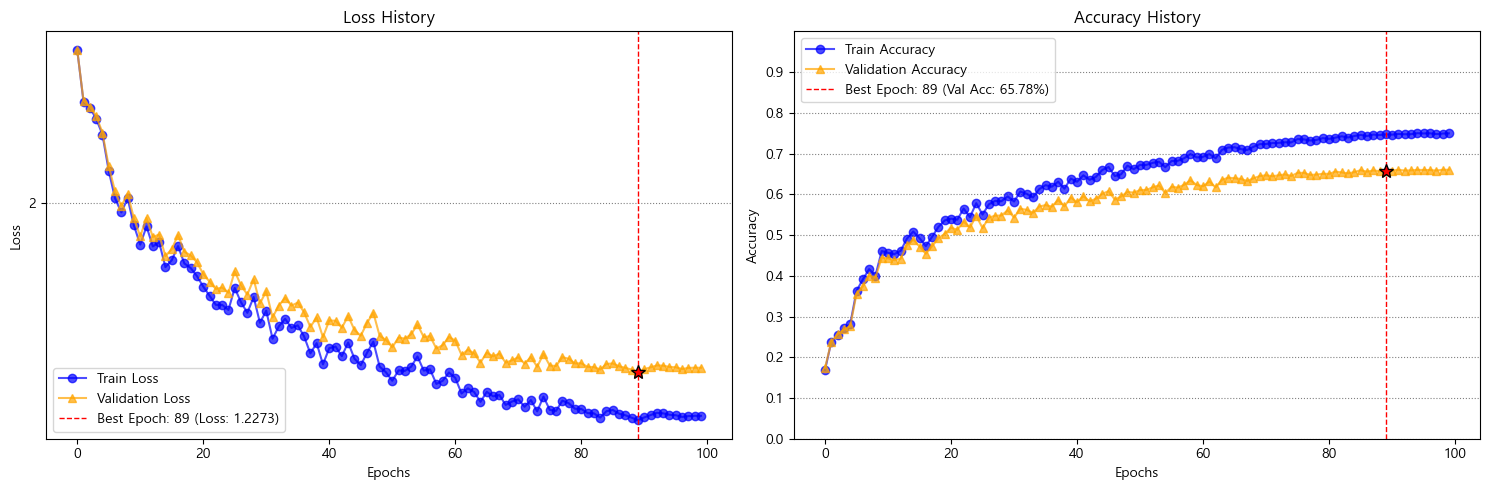

In [19]:
# History 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Validation Loss가 최소인 epoch 찾기
best_epoch_idx = np.argmin(history['val_loss'])
min_val_loss = history['val_loss'][best_epoch_idx]
val_acc_at_best_loss = history['val_acc'][best_epoch_idx]

# Loss
ax1.plot(history['train_loss'], marker='o', linestyle='-', label='Train Loss', color='blue', alpha=0.7)
ax1.plot(history['val_loss'], marker='^', linestyle='-', label='Validation Loss', color='orange', alpha=0.7)
ax1.set_title('Loss History')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')

# y축 그리드 설정 (2 간격)
y_min_loss, y_max_loss = ax1.get_ylim()
ax1.set_yticks(np.arange(np.floor(y_min_loss / 2) * 2, np.ceil(y_max_loss / 2) * 2 + 2, 2)) # 2 간격으로 눈금 설정
ax1.grid(axis='y', linestyle=':', color='gray')

# 최소 Validation Loss 지점 표시
ax1.axvline(x=best_epoch_idx, color='red', linestyle='--', linewidth=1, label=f'Best Epoch: {best_epoch_idx} (Loss: {min_val_loss:.4f})')
ax1.plot(best_epoch_idx, min_val_loss, marker='*', markersize=10, color='red', linestyle='None', markeredgecolor='black')
ax1.legend()

# Accuracy
ax2.plot(history['train_acc'], marker='o', linestyle='-', label='Train Accuracy', color='blue', alpha=0.7)
ax2.plot(history['val_acc'], marker='^', linestyle='-', label='Validation Accuracy', color='orange', alpha=0.7)
ax2.set_title('Accuracy History')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')

# y축 범위 및 그리드 설정 (0.0 ~ 0.9, 0.1 간격)
ax2.set_ylim(0.0, 1.0)
ax2.set_yticks(np.arange(0.0, 0.91, 0.1)) # 0.1 간격으로 눈금 설정
ax2.grid(axis='y', linestyle=':', color='gray')

# 최소 Validation Loss 지점 (Accuracy 플롯에도 동일 epoch 표시)
ax2.axvline(x=best_epoch_idx, color='red', linestyle='--', linewidth=1, label=f'Best Epoch: {best_epoch_idx} (Val Acc: {val_acc_at_best_loss*100:2.2f}%)')
ax2.plot(best_epoch_idx, val_acc_at_best_loss, marker='*', markersize=10, color='red', linestyle='None', markeredgecolor='black')
ax2.legend()

plt.tight_layout()
plt.show()